# 🔮 Notebook 5 — Facebook Prophet
**Goal:** Use Prophet's built-in trend + seasonality + holidays framework, with custom Indian holiday calendar.

**Contents:**
1. Setup & Data
2. Build Indian Holidays DataFrame
3. Fit Prophet (multiplicative mode + extra regressors)
4. Forecast vs Actual
5. Component Decomposition
6. 90-day Future Forecast
7. Metrics


## 1. Setup & Data

In [2]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
warnings.filterwarnings("ignore")
os.makedirs("plots",exist_ok=True); os.makedirs("models",exist_ok=True)

DATA_PATH  = r"data\UPI_Master_2021_2026_Mar.csv"
TRAIN_END  = "2025-09-30"; TEST_START = "2025-10-01"
BLUE,RED,ORANGE,GREEN = "#1A6FBF","#D62728","#E07B39","#2CA02C"
plt.rcParams.update({"figure.facecolor":"#FAFAFA","axes.facecolor":"#FAFAFA",
    "axes.grid":True,"grid.alpha":0.3,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False})

def evaluation_metrics(actual,predicted):
    a,p=np.array(actual),np.array(predicted)
    return {"MAE":round(np.mean(np.abs(a-p)),4),
            "RMSE":round(np.sqrt(np.mean((a-p)**2)),4),
            "MAPE":round(np.mean(np.abs((a-p)/a))*100,4)}

df    = pd.read_csv(DATA_PATH,parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
df["Festival_Name"] = df["Festival_Name"].fillna("")
for col in ["Is_Weekend","Is_Festival","Is_Long_Weekend","Holiday_Cluster_7D"]:
    df[col] = df[col].astype(float)
train = df[df["Date"]<=TRAIN_END]; test=df[df["Date"]>=TEST_START]

TARGET = "Volume (In Mn.)"   # ← change to "Value (In Cr.)" for value
print(f"Train: {len(train):,}  Test: {len(test):,}")


Train: 1,614  Test: 182


## 2. Build Indian Holidays DataFrame

In [3]:
holidays_raw = {
    "2021-01-26":"Republic Day","2021-03-29":"Holi","2021-04-02":"Good Friday",
    "2021-04-21":"Ram Navami","2021-05-01":"Maharashtra Day","2021-07-21":"Eid ul-Adha",
    "2021-08-15":"Independence Day","2021-08-30":"Janmashtami","2021-10-02":"Gandhi Jayanti",
    "2021-10-15":"Dussehra","2021-11-04":"Diwali","2021-11-19":"Guru Nanak Jayanti",
    "2021-12-25":"Christmas",
    "2022-01-26":"Republic Day","2022-03-18":"Holi","2022-04-14":"Dr. Ambedkar Jayanti",
    "2022-04-15":"Good Friday","2022-05-01":"Maharashtra Day","2022-08-09":"Muharram",
    "2022-08-15":"Independence Day","2022-08-19":"Janmashtami","2022-10-02":"Gandhi Jayanti",
    "2022-10-05":"Dussehra","2022-10-24":"Diwali","2022-11-08":"Guru Nanak Jayanti",
    "2022-12-25":"Christmas",
    "2023-01-26":"Republic Day","2023-03-08":"Holi","2023-04-07":"Good Friday",
    "2023-04-14":"Dr. Ambedkar Jayanti","2023-05-01":"Maharashtra Day",
    "2023-06-29":"Eid ul-Adha","2023-08-15":"Independence Day",
    "2023-09-07":"Janmashtami","2023-10-02":"Gandhi Jayanti","2023-10-24":"Dussehra",
    "2023-11-13":"Diwali","2023-11-27":"Guru Nanak Jayanti","2023-12-25":"Christmas",
    "2024-01-26":"Republic Day","2024-03-25":"Holi","2024-04-14":"Dr. Ambedkar Jayanti",
    "2024-04-19":"Good Friday","2024-05-01":"Maharashtra Day","2024-06-17":"Eid ul-Adha",
    "2024-08-15":"Independence Day","2024-08-26":"Janmashtami","2024-10-02":"Gandhi Jayanti",
    "2024-10-12":"Dussehra","2024-11-01":"Diwali","2024-11-15":"Guru Nanak Jayanti",
    "2024-12-25":"Christmas",
    "2025-01-26":"Republic Day","2025-03-14":"Holi","2025-03-31":"Eid ul-Fitr",
    "2025-04-18":"Good Friday","2025-05-01":"Maharashtra Day","2025-06-07":"Eid ul-Adha",
    "2025-08-15":"Independence Day","2025-08-16":"Janmashtami","2025-10-02":"Gandhi Jayanti",
    "2025-10-20":"Diwali","2025-11-05":"Guru Nanak Jayanti","2025-12-25":"Christmas",
}

holidays_df = pd.DataFrame([
    {"ds": pd.Timestamp(d), "holiday": name, "lower_window": -1, "upper_window": 1}
    for d, name in holidays_raw.items()
])
print(f"Holiday records: {len(holidays_df)}")
holidays_df.head()


Holiday records: 64


,ds,holiday,lower_window,upper_window
0,2021-01-26,Republic Day,-1,1
1,2021-03-29,Holi,-1,1
2,2021-04-02,Good Friday,-1,1
3,2021-04-21,Ram Navami,-1,1
4,2021-05-01,Maharashtra Day,-1,1


## 3. Fit Prophet

In [4]:
EXTRA_REGS = ["Is_Weekend","Is_Festival","Is_Long_Weekend","Holiday_Cluster_7D"]

train_df = train[["Date",TARGET]+EXTRA_REGS].rename(columns={"Date":"ds",TARGET:"y"})
test_df  = test[["Date",TARGET]+EXTRA_REGS].rename(columns={"Date":"ds",TARGET:"y"})

model = Prophet(
    holidays=holidays_df,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    interval_width=0.95,
)
for col in EXTRA_REGS:
    model.add_regressor(col)

print("Fitting Prophet...")
model.fit(train_df)
print("Done!")


Fitting Prophet...


11:17:56 - cmdstanpy - INFO - Chain [1] start processing
11:17:58 - cmdstanpy - INFO - Chain [1] done processing


Done!


## 4. Forecast vs Actual

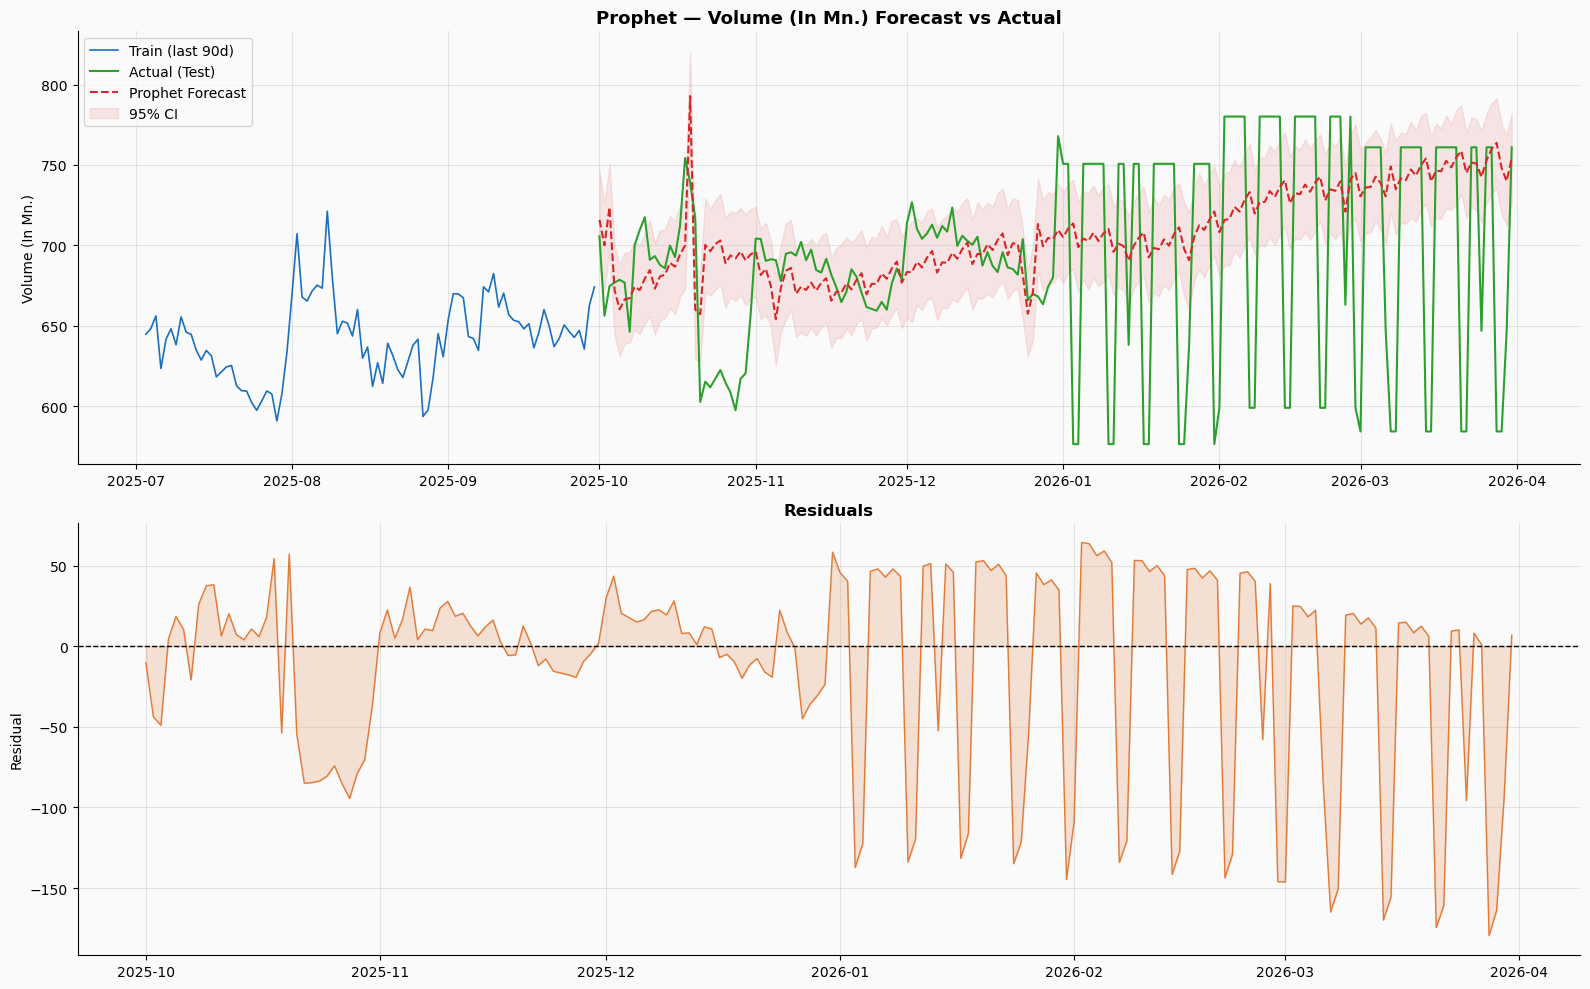

In [5]:
forecast = model.predict(test_df)
yhat, yhat_lower, yhat_upper = forecast["yhat"].values, forecast["yhat_lower"].values, forecast["yhat_upper"].values
actual, dates = test_df["y"].values, test_df["ds"].values

fig, axes = plt.subplots(2,1,figsize=(16,10))
axes[0].plot(train_df["ds"].tail(90), train_df["y"].tail(90), color=BLUE, lw=1.2, label="Train (last 90d)")
axes[0].plot(dates, actual, color=GREEN, lw=1.5, label="Actual (Test)")
axes[0].plot(dates, yhat,   color=RED, lw=1.5, linestyle="--", label="Prophet Forecast")
axes[0].fill_between(dates, yhat_lower, yhat_upper, color=RED, alpha=0.1, label="95% CI")
axes[0].set_title(f"Prophet — {TARGET} Forecast vs Actual", fontsize=13, fontweight="bold")
axes[0].set_ylabel(TARGET); axes[0].legend()

residuals = actual - yhat
axes[1].plot(dates, residuals, color=ORANGE, lw=1.0)
axes[1].axhline(0,color="black",lw=1,linestyle="--")
axes[1].fill_between(dates, residuals, 0, alpha=0.2, color=ORANGE)
axes[1].set_title("Residuals",fontweight="bold"); axes[1].set_ylabel("Residual")
plt.tight_layout()
plt.savefig(f"plots/17_prophet_{TARGET[:3].lower()}.png",dpi=150,bbox_inches="tight")
plt.show()


## 5. Component Decomposition

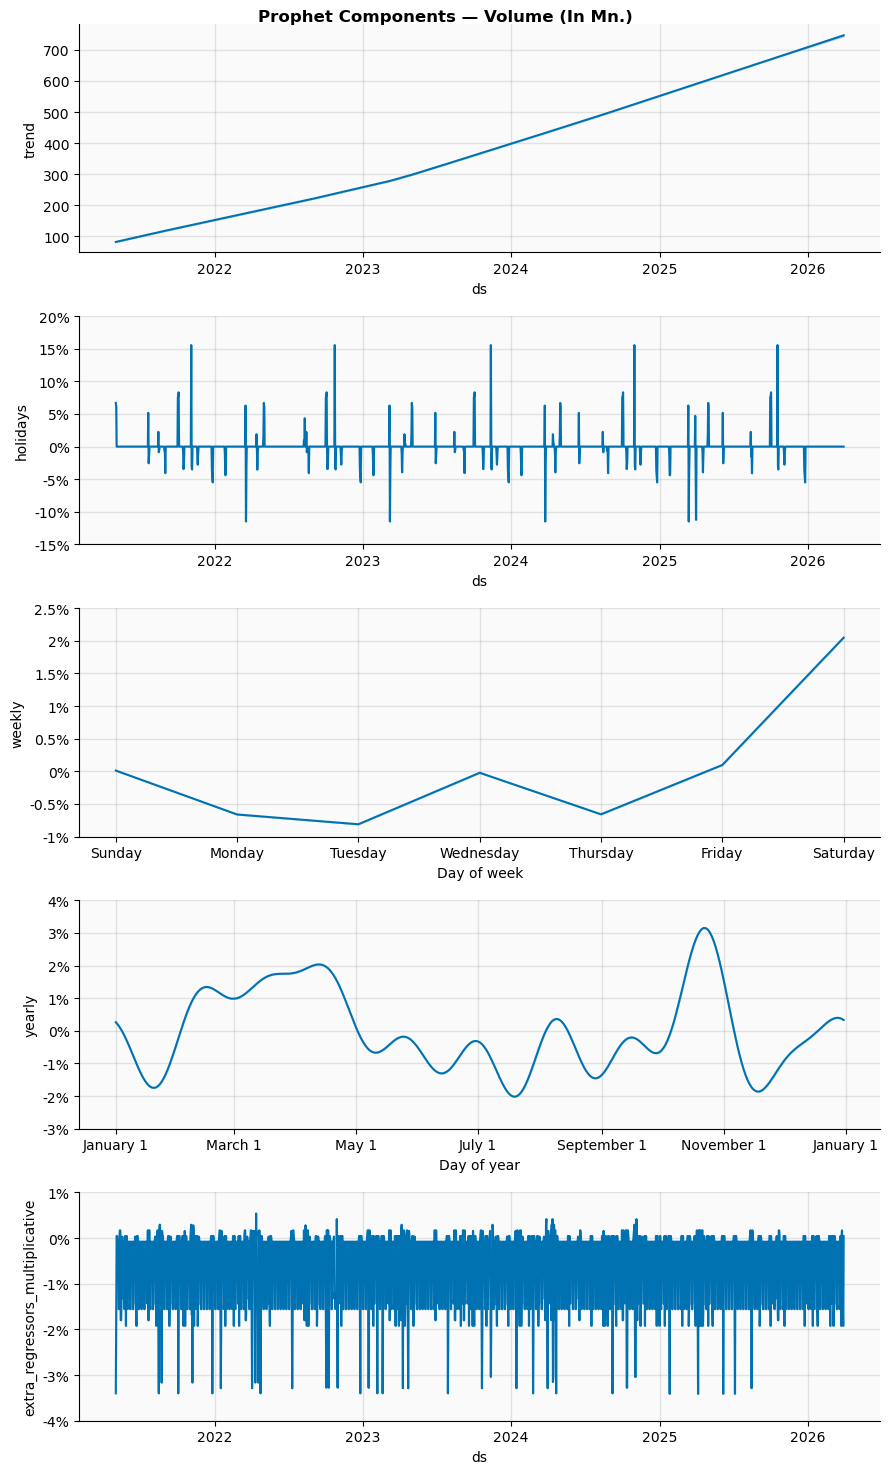

In [6]:
full_df  = pd.concat([train_df,test_df],ignore_index=True)
full_fc  = model.predict(full_df)
fig = model.plot_components(full_fc)
fig.suptitle(f"Prophet Components — {TARGET}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"plots/17b_prophet_components_{TARGET[:3].lower()}.png",dpi=150,bbox_inches="tight")
plt.show()


## 6. Future 90-day Forecast

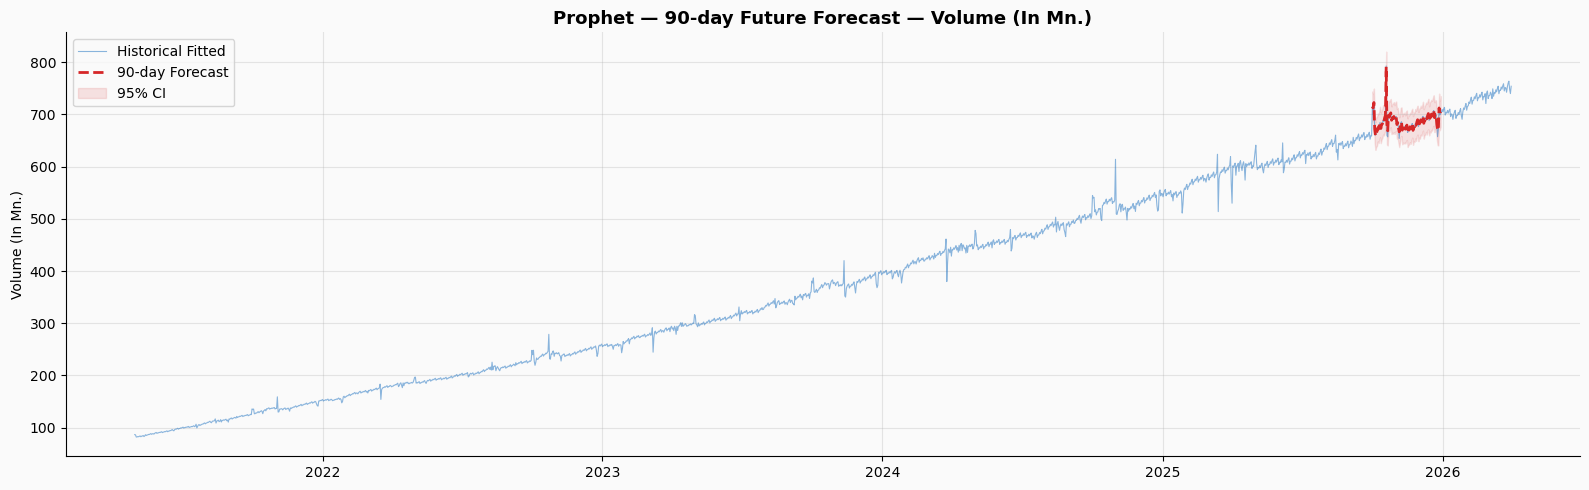

In [7]:
future = model.make_future_dataframe(periods=90, freq="D")
for col in EXTRA_REGS:
    if col=="Is_Weekend":
        future[col] = (pd.to_datetime(future["ds"]).dt.dayofweek>=5).astype(float)
    else:
        future[col] = 0.0

future_fc   = model.predict(future)
future_only = future_fc[future_fc["ds"] > train_df["ds"].max()]

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(full_fc["ds"], full_fc["yhat"], color=BLUE, lw=0.8, alpha=0.5, label="Historical Fitted")
ax.plot(future_only["ds"], future_only["yhat"], color=RED, lw=2.0, linestyle="--", label="90-day Forecast")
ax.fill_between(future_only["ds"], future_only["yhat_lower"], future_only["yhat_upper"],
                color=RED, alpha=0.12, label="95% CI")
ax.set_title(f"Prophet — 90-day Future Forecast — {TARGET}", fontsize=13, fontweight="bold")
ax.set_ylabel(TARGET); ax.legend()
plt.tight_layout()
plt.savefig(f"plots/17c_prophet_future_{TARGET[:3].lower()}.png",dpi=150,bbox_inches="tight")
plt.show()


## 7. Metrics & Save

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
metrics = evaluation_metrics(actual, yhat)
print(f"Test Set Metrics — Prophet on {TARGET}")
print(f"  MAE  : {metrics['MAE']:.4f}")
print(f"  RMSE : {metrics['RMSE']:.4f}")
print(f"  MAPE : {metrics['MAPE']:.2f}%")

with open(f"models/prophet_{TARGET[:3].lower()}_metrics.json","w") as f:
    json.dump({"model":"Prophet","target":TARGET,**metrics},f,indent=2)
print("✅ Metrics saved.")


Test Set Metrics — Prophet on Volume (In Mn.)
  MAE  : 46.9433
  RMSE : 64.8604
  MAPE : 7.25%
✅ Metrics saved.


In [10]:
import numpy as np, json, os
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet forecast is usually in a dataframe called forecast or future
# The test actuals are usually in test or df_test

# Align forecast to test period
test_forecast = forecast[forecast["ds"].isin(test["Date"])]["yhat"].values
test_actual   = test["Volume (In Mn.)"].values

mae  = mean_absolute_error(test_actual, test_forecast)
rmse = np.sqrt(mean_squared_error(test_actual, test_forecast))
mape = np.mean(np.abs((test_actual - test_forecast) / (test_actual + 1e-9))) * 100

print(f"MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

os.makedirs("../models", exist_ok=True)
with open("../models/prophet_volume_metrics.json", "w") as f:
    json.dump({"model":"Prophet","target":"Volume (In Mn.)",
               "MAE":round(mae,2),"RMSE":round(rmse,2),"MAPE":round(mape,2)}, f)
print("Saved")

MAE=46.94  RMSE=64.86  MAPE=7.25%
Saved


In [11]:
import json, os

os.makedirs("../models", exist_ok=True)

prophet_metrics = {
    "model":  "Prophet",
    "target": "Volume (In Mn.)",
    "MAE":    round(mae_prophet, 2),
    "RMSE":   round(rmse_prophet, 2),
    "MAPE":   round(mape_prophet, 2),
}

with open("../models/prophet_volume_metrics.json", "w") as f:
    json.dump(prophet_metrics, f)

print("Saved:", prophet_metrics)

NameError: name 'mae_prophet' is not defined